<a href="https://colab.research.google.com/github/RudolfVonStroheim/PopulationClassifier/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas-plink
from pandas_plink import read_plink

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 951.9 kB/s eta 0:00:00
INFO: pip is looking at multiple versions of numpy-typing-compat to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.4/79.4 kB 3.2 MB/s eta 0:00:00
ERROR: Operation cancelled by user
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 377, in run
    requirement_set = resolver.resolve(
                      ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/resolution/resolveli

KeyboardInterrupt: 

In [19]:
!curl -O http://www.russiangenome.ru/biengi.zip
!unzip biengi.zip -d biengi

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 33.0M  100 33.0M    0     0  2199k      0  0:00:15  0:00:15 --:--:-- 5408k
Archive:  biengi.zip
replace biengi/biengi.bed? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
!wget https://s3.amazonaws.com/plink2-assets/plink2_linux_x86_64_latest.zip -O plink.zip # Скачиваем plink(стандарт в биоинформатике)
!unzip -q -n plink.zip plink2

--2026-06-03 09:06:50--  https://s3.amazonaws.com/plink2-assets/plink2_linux_x86_64_latest.zip
Resolving s3.amazonaws.com (s3.amazonaws.com)... 52.217.137.168, 52.217.136.176, 16.15.191.245, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|52.217.137.168|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7618716 (7.3M) [application/zip]
Saving to: ‘plink.zip’

plink.zip           100%[===================>]   7.27M  48.3MB/s    in 0.2s    

2026-06-03 09:06:51 (48.3 MB/s) - ‘plink.zip’ saved [7618716/7618716]



Данные хранятся в формате SNP(Single Nucleotide Polymorphism): в первом столбце хранится id семьи, во втором - id человека, далее хранятся вариации некоторых генов, встречающихся у этого человека(известны все мутации гена, мутация у конкретного человека описывается номером, номера с вариантами нуклеотидов сопостваляются в отдельном файле(biengi.bim)

In [ ]:
!mkdir pruned
!./plink2 --bfile biengi/biengi --indep-pairwise 50 5 0.2 --out biengi/biengi_pruned # Прунинг датасета(мажно сделать средствами python, но так занимает меньше времени)
!./plink2 --bfile biengi/biengi --extract biengi/biengi_pruned.prune.in --make-bed --out pruned/data_pruned

PLINK v2.0.0-a.7.0LM 64-bit Intel (25 Apr 2026)     cog-genomics.org/plink/2.0/
(C) 2005-2026 Shaun Purcell, Christopher Chang    GNU General Public License v3
Logging to biengi/biengi_pruned.log.
Options in effect:
  --bfile biengi/biengi
  --indep-pairwise 50 5 0.2
  --out biengi/biengi_pruned

Start time: Wed Jun  3 09:06:51 2026
12975 MiB RAM detected, ~11700 available; reserving 6487 MiB for main
workspace.
Using up to 2 compute threads.
894 samples (320 females, 574 males; 894 founders) loaded from
biengi/biengi.fam.
242180 variants loaded from biengi/biengi.bim.
Note: No phenotype data present.
Calculating allele frequencies... 0%27%54%81%done.
--indep-pairwise (2 compute threads): 0%50%162922/242180 variants removed.
Variant lists written to biengi/biengi_pruned.prune.in and
biengi/biengi_pruned.prune.out .
End time: Wed Jun  3 09:06:52 2026
PLINK v2.0.0-a.7.0LM 64-bit Intel (25 Apr 2026)     cog-genomics.org/plink/2.0/
(C) 2005-2026 Shaun Purcell, Christopher C

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
import seaborn as sns

In [ ]:
# До прунинга
bim, fam, G = read_plink("biengi/biengi")
gn = pd.DataFrame(G.compute().T)
gn

Mapping files: 100%|██████████| 3/3 [00:00<00:00,  6.20it/s]
/usr/local/lib/python3.12/dist-packages/pandera/_pandas_deprecated.py:143: FutureWarning: Importing pandas-specific classes and functions from the
top-level pandera module will be **removed in a future version of pandera**.
If you're using pandera to validate pandas objects, we highly recommend updating
your import:

```
# old import
import pandera as pa

# new import
import pandera.pandas as pa
```

If you're using pandera to validate objects from other compatible libraries
like pyspark or polars, see the supported libraries section of the documentation
for more information on how to import pandera:

https://pandera.readthedocs.io/en/stable/supported_libraries.html

To disable this warning, set the environment variable:

```
export DISABLE_PANDERA_IMPORT_WARNING=True
```

  warnings.warn(_future_warning, FutureWarning)


,0,1,2,3,4,5,6,7,8,9,...,242170,242171,242172,242173,242174,242175,242176,242177,242178,242179
0,1.0,2.0,1.0,2.0,1.0,1.0,2.0,1.0,2.0,2.0,...,2.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,2.0,2.0
1,1.0,2.0,2.0,1.0,2.0,2.0,2.0,0.0,2.0,1.0,...,1.0,2.0,2.0,1.0,2.0,1.0,2.0,2.0,2.0,2.0
2,2.0,1.0,1.0,2.0,2.0,1.0,2.0,1.0,2.0,1.0,...,2.0,1.0,1.0,1.0,1.0,2.0,0.0,2.0,2.0,2.0
3,2.0,2.0,2.0,1.0,2.0,2.0,2.0,1.0,2.0,1.0,...,0.0,2.0,2.0,2.0,2.0,2.0,1.0,0.0,1.0,1.0
4,1.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,1.0,...,2.0,0.0,0.0,1.0,1.0,2.0,1.0,1.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
889,1.0,2.0,0.0,2.0,0.0,0.0,0.0,1.0,1.0,1.0,...,1.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
890,2.0,1.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0,0.0,...,2.0,1.0,1.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0
891,2.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,2.0,...,2.0,2.0,2.0,1.0,0.0,2.0,1.0,2.0,2.0,2.0
892,2.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,0.0,...,1.0,1.0,1.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0


In [ ]:
#После прунинга
bim, fam, G = read_plink("pruned/data_pruned")
gn_p = G.compute().T
imp = SimpleImputer(strategy="mean")
gn_p = pd.DataFrame(imp.fit_transform(gn_p))
gn_p.head()

Mapping files: 100%|██████████| 3/3 [00:00<00:00, 21.13it/s]


,0,1,2,3,4,5,6,7,8,9,...,79248,79249,79250,79251,79252,79253,79254,79255,79256,79257
0,1.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,...,1.0,2.0,2.0,1.0,2.0,1.0,2.0,1.0,1.0,2.0
1,1.0,2.0,1.0,2.0,0.0,1.0,2.0,1.0,2.0,2.0,...,2.0,1.0,1.0,0.0,2.0,2.0,1.0,2.0,2.0,2.0
2,2.0,1.0,2.0,2.0,1.0,1.0,2.0,2.0,2.0,2.0,...,2.0,1.0,0.0,1.0,2.0,1.0,2.0,0.0,2.0,2.0
3,2.0,2.0,1.0,2.0,1.0,1.0,2.0,2.0,2.0,2.0,...,1.0,2.0,1.0,0.0,2.0,2.0,2.0,1.0,0.0,1.0
4,1.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,1.0,2.0,...,1.0,2.0,1.0,1.0,2.0,1.0,2.0,1.0,1.0,2.0


В результате LD-прунинга количество признаков удалось существенно сократить.
Необходимость данного метода обуславливается спецификой данных: в геноме большое количество блоков очень часто наследуются вместе и при обработке необходимо учитывать весь блок целиком, а не его фрагменты. В итоге число признаков сократилось чуть более, чем в три раза.

Принцип работы алгоритма: датасет сканируется скользящим окном с шириной 500 SNP и шагом 50, для каждой пары SNP считается ковариация. Если квадрат ковариации оказывается больше порога(0.2), один из столбцов удаляется.

In [ ]:
!./plink2 --pca 20 --autosome --bfile pruned/data_pruned --out pruned/end_data # Применяем анализ главных компонент

PLINK v2.0.0-a.7.0LM 64-bit Intel (25 Apr 2026)     cog-genomics.org/plink/2.0/
(C) 2005-2026 Shaun Purcell, Christopher Chang    GNU General Public License v3
Logging to pruned/end_data.log.
Options in effect:
  --autosome
  --bfile pruned/data_pruned
  --out pruned/end_data
  --pca 20

Start time: Wed Jun  3 09:06:56 2026
12975 MiB RAM detected, ~11612 available; reserving 6487 MiB for main
workspace.
Using up to 2 compute threads.
894 samples (320 females, 574 males; 894 founders) loaded from
pruned/data_pruned.fam.
79258 variants loaded from pruned/data_pruned.bim (--autosome had no effect).
Note: No phenotype data present.
Calculating allele frequencies... 0%82%done.
Constructing GRM: 0%1%2%3%4%5%6%7%8%9%10%11%12%13%14%15%16%17%18%19%20%21%22%23%24%25%26%27%28%29%30%31%32%33%34%35%36%37%38%39%40%41%42%43%44%45%46%47%48%49%50%51%52%

In [ ]:
vecs = pd.read_csv("pruned/end_data.eigenvec", sep="\t") # Сам набор данных после обработки, необходимое количество главных компонент определится в процессе обучения
vecs.head()

,#FID,IID,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,...,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20
0,4461875510_R01C01,4461875510_R01C01,0.023074,0.045581,0.022737,0.010032,-0.007578,0.006535,-0.013364,-0.006449,...,-0.011568,0.013319,-0.104406,-0.027199,-0.065530,0.028127,0.032088,-0.020976,0.049659,-0.001013
1,4461875510_R01C02,4461875510_R01C02,0.029373,0.032638,0.032961,0.009149,-0.009421,0.015256,-0.004736,-0.005012,...,-0.006650,-0.004943,-0.028420,0.002378,0.003861,-0.001194,-0.022291,-0.006184,0.009597,0.017944
2,4461875510_R02C01,4461875510_R02C01,0.025983,0.044283,0.023562,0.005499,-0.006325,0.020146,-0.013274,-0.011976,...,0.001390,0.003786,-0.088619,-0.056395,-0.089733,0.034666,0.040777,-0.028939,0.034347,0.031454
3,4461875513_R02C02,4461875513_R02C02,0.022607,0.046587,0.025225,0.014595,-0.009510,0.007256,-0.023022,-0.030881,...,-0.007591,-0.018424,-0.100844,-0.056442,-0.077844,0.065486,0.008322,-0.010986,0.018294,0.033148
4,4461875513_R01C02,4461875513_R01C02,0.024328,0.042327,0.017202,0.009732,-0.007187,0.014206,-0.007818,-0.012584,...,0.001914,-0.008715,-0.094569,-0.052297,-0.104056,0.021057,-0.000512,-0.021899,0.053384,0.008248


In [ ]:
tags = pd.read_csv("biengi/biengi.pedind", sep="\t", header=None, usecols=[0, 1, 5], names=["FID", "IID", "Population"]) # Метки(поля - ID семьи, идентификационный ключ, сама раса)
tags.head()

,FID,IID,Population
0,4461875510_R01C01,4461875510_R01C01,Karel
1,4461875510_R01C02,4461875510_R01C02,Karel
2,4461875510_R02C01,4461875510_R02C01,Karel
3,4461875513_R02C02,4461875513_R02C02,Karel
4,4461875513_R01C02,4461875513_R01C02,Karel


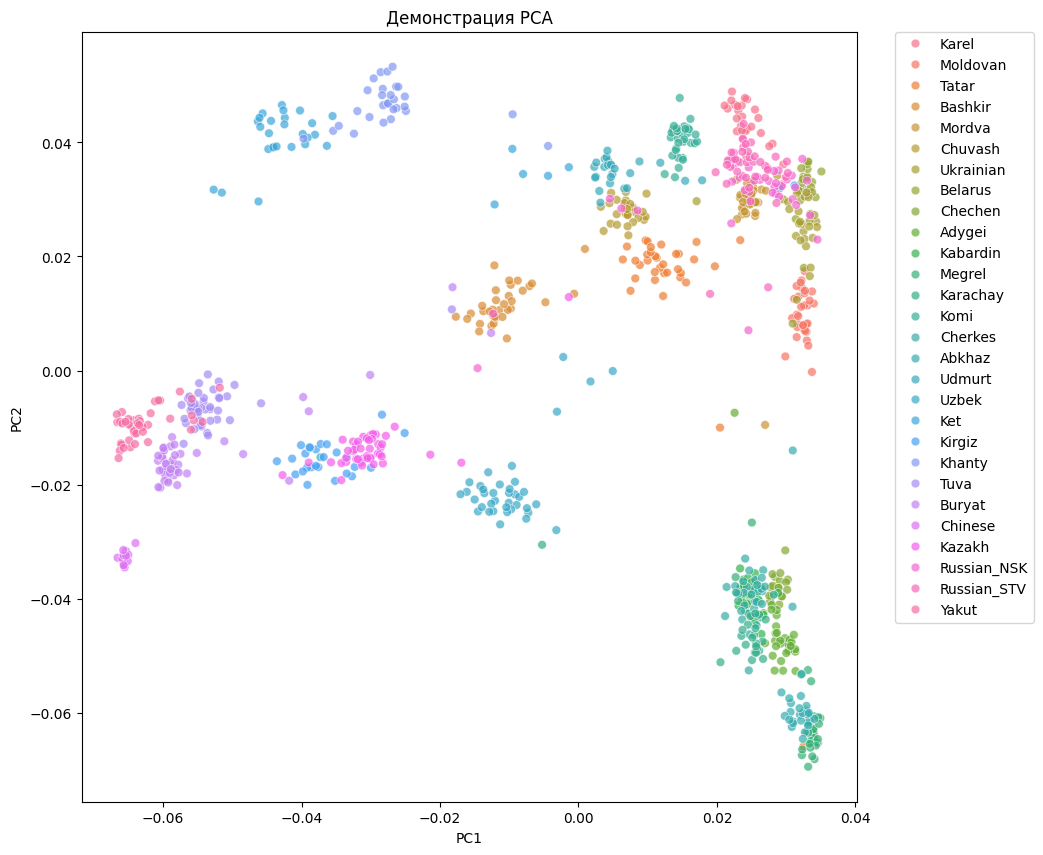

In [ ]:
graph = pd.DataFrame({"PC1": vecs["PC1"], "PC2": vecs["PC2"], "PC3": vecs["PC3"], "Population": tags["Population"]})
plt.figure(figsize=(10, 10))
sns.scatterplot(data=graph, x="PC1", y="PC2", hue="Population", s=40, alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0)
plt.title("Демонстрация PCA")
plt.show()

Как видно, уже с помощью первых двух главных компонент можно получить большую часть информации о датасете, что позволяет существенно упростить модели и ускорить обучение. Однако, в результате применения данного метода теряются исходные признаки, что делает анализ представленных данных существенно труднее.

In [ ]:
"""Основной цикл обучения, объект модели формирует фабрика"""
def train_and_predict(model_class, all_data, pc_max_count, epochs_count):
  scores = []
  pcas = list(range(2, pc_max_count + 1))
  for i in pcas:
    x_tr, x_test, y_tr, y_test = train_test_split(all_data.iloc[:, :i], all_data['Population'], test_size=0.2, random_state=42)
    model = model_class(epochs_count)
    model.fit(x_tr, y_tr)
    score = cross_val_score(model, x_tr, y_tr, cv=5).mean()
    scores.append(score)
  plt.plot(pcas, scores)
  plt.title("Model scores on different PC counts")
  plt.xlabel("PC count")
  plt.ylabel("Accuracy score")
  plt.xticks(pcas)
  plt.show()
  return model
populations = list(np.unique(tags['Population'])) # Превращаем текстовые метки в числа
y = [populations.index(i) for i in tags['Population']]
all_data = vecs.iloc[:, 2:]
all_data['Population'] = y

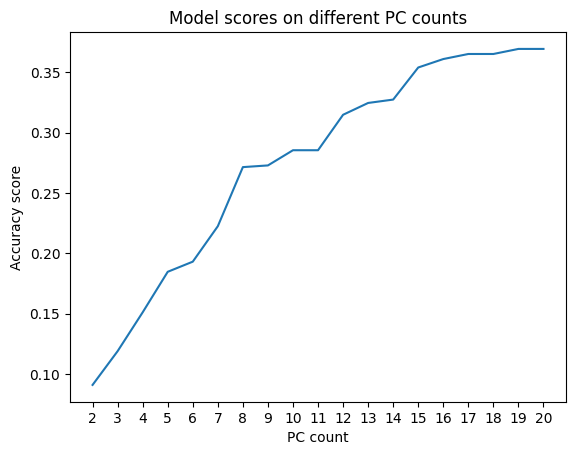

In [ ]:
def logistic(epochs):
  return LogisticRegression(solver="lbfgs", max_iter=epochs)
model = train_and_predict(logistic, all_data, 20, 50)

In [ ]:
x_tr, x_test, y_tr, y_test = train_test_split(all_data.iloc[:, :15], all_data['Population'], test_size=0.2, random_state=42)
model = logistic(50)
model.fit(x_tr, y_tr)
y_pred = model.predict(x_test)
print(classification_report(y_test, y_pred))
populations[2]

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.00      0.00      0.00         6
           2       1.00      1.00      1.00         8
           3       0.00      0.00      0.00         3
           4       0.42      1.00      0.59         5
           5       0.00      0.00      0.00         7
           6       0.00      0.00      0.00         4
           7       0.00      0.00      0.00         4
           8       1.00      1.00      1.00         2
           9       0.00      0.00      0.00         5
          10       0.00      0.00      0.00         5
          11       1.00      0.50      0.67         4
          12       0.04      1.00      0.08         5
          13       1.00      1.00      1.00         3
          14       1.00      1.00      1.00         3
          15       0.00      0.00      0.00        10
          16       1.00      0.71      0.83         7
          17       0.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


'Bashkir'

Логистическая регрессия
Принцип для двух классов:
Градиентным спуском подбираем параметры гиперплоскости $\Sigma_{i = 1}^nb_ix_i + k = 0$
Прогноз: $\sigma$ от расстояния от точки до гиперплоскости со знаком + если точка выше плоскости, иначе -, где $\sigma(x) = \frac{1}{1 + e^{-x}}$
Для n классов используются n логистическиз классификаторов, определяющих принадлежность к каждому классу, вместо сигмоиды используется softmax от всех прогнозов.
$softmax(x_i) = \frac{e^(x_i)}{\Sigma_{j=1}^ne^x_j}$
Итоги: оптимальное количество используемых главных компонент - 15. На этом этапе логистический классификатор уже может выделить некоторые популяции со стапроцентной точностью и близкой к 1 полнотой, а некоторые популяции определены с f1-метрикой 1, то есть, с точностью и полнотой 1, но очень много популяций не классифицируются вообще. Предположение: на распределении популяций по первым двум главным компонентам отчётливо выделяются кластеры, состоящие из нескольких популяций. Логистическая регрессия выделила эти кластеры и отнесла их к одной популяции.
Итоговая точность: 0.3(в десять раз больше вероятности угадать случайно)

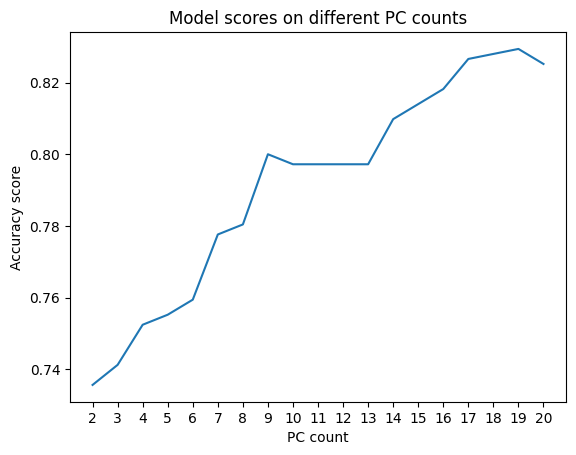

In [26]:
def bayes(epochs):
  return GaussianNB()
model = train_and_predict(bayes, all_data, 20, 100)

In [ ]:
x_tr, x_test, y_tr, y_test = train_test_split(all_data.iloc[:, :17], all_data['Population'], test_size=0.2, random_state=42)
model = bayes(100)
model.fit(x_tr, y_tr)
y_pred = model.predict(x_test)
print(classification_report(y_test, y_pred))
populations[6]

              precision    recall  f1-score   support

           0       0.75      0.50      0.60         6
           1       1.00      1.00      1.00         6
           2       1.00      1.00      1.00         8
           3       0.25      0.67      0.36         3
           4       1.00      1.00      1.00         5
           5       1.00      1.00      1.00         7
           6       0.50      0.50      0.50         4
           7       1.00      1.00      1.00         4
           8       1.00      1.00      1.00         2
           9       0.50      0.60      0.55         5
          10       1.00      1.00      1.00         5
          11       1.00      1.00      1.00         4
          12       0.36      1.00      0.53         5
          13       1.00      1.00      1.00         3
          14       1.00      1.00      1.00         3
          15       1.00      0.10      0.18        10
          16       1.00      1.00      1.00         7
          17       0.73    

'Cherkes'

Модель Байеса.\
Модель, основанная на теореме Байеса\
$$P(y_k|X) = \frac{P(y_k)P(X|y_k)}{P(X)}$$
Где $P(y_k|X) - апостериорная\ вероятность\ принадлежности\ объекта\ к\ классу\ X\ с\ учётом\ его\ признаков\ y_k$
$P(y_k) -\ априорная\ вероятность\ такого\ набора\ признаков$
$P(X|y_k) -\ правдоподобие, то\ есть\ вероятность\ наличия\ признаков\ при\ заданном\ классе.$
$P(x) - априорная\ вероятность\ принадлежности\ к\ классу\ X.$
Здесь признаки считаются независимыми, что позволяет нам предположить, что
$P(y_k) = Π_{i=1}^ky_i$ \
Поскольку изначально говорится о дискретных признаках, а в нашем случае признаки непрерывны используется Гауссианский классификатор, предполагающий, что признаки имеют стандартное распределение по закону Гаусса
$$P(X|y_i) = \frac{1}{\sqrt{2\pi\sigma_y^2}}exp(-\frac{(y_i - \mu_i)^2}{2\sigma_i})$$
Где $\sigma_i, \mu_i$ - стандартное и среднее отклонения признаков в классе X.\
Для нескольких классов используется схожий с описанным ранее подход. \
Данная модель при всей своей простоте показала на удивление хорошие результаты, сравнимые с рассматриваемыми ниже ансамблевыми моделями.

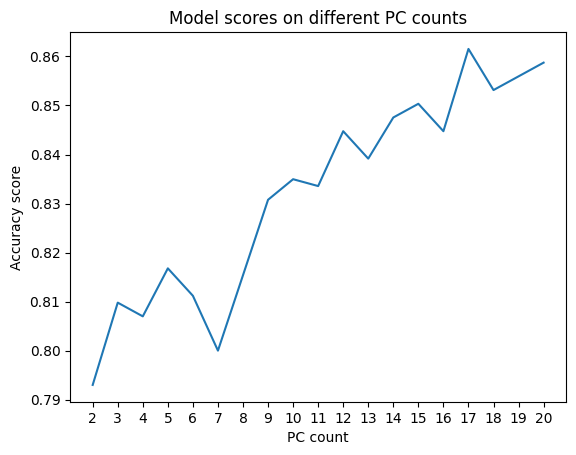

In [ ]:
def forest(epochs):
  return RandomForestClassifier(n_estimators=epochs)
model = train_and_predict(forest, all_data, 20, 100)

In [ ]:
x_tr, x_test, y_tr, y_test = train_test_split(all_data.iloc[:, :20], all_data['Population'], test_size=0.2, random_state=42)
model = forest(100)
model.fit(x_tr, y_tr)
y_pred = model.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      1.00      0.92         6
           1       1.00      1.00      1.00         6
           2       1.00      1.00      1.00         8
           3       0.29      0.67      0.40         3
           4       1.00      1.00      1.00         5
           5       1.00      1.00      1.00         7
           6       0.40      0.50      0.44         4
           7       1.00      1.00      1.00         4
           8       1.00      1.00      1.00         2
           9       0.50      0.40      0.44         5
          10       1.00      1.00      1.00         5
          11       1.00      1.00      1.00         4
          12       0.56      1.00      0.71         5
          13       1.00      1.00      1.00         3
          14       1.00      1.00      1.00         3
          15       0.83      0.50      0.62        10
          16       1.00      1.00      1.00         7
          17       0.92    

## Случайный лес
Первый рассматриваемый здесь ансамблевый метод предполагает использование большого количества деревьев решений

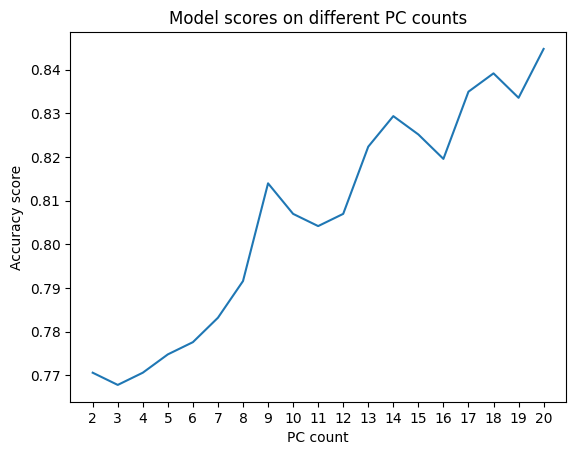

In [ ]:
def xgboost(epochs):
  return XGBClassifier(n_estimators=epochs)
model = train_and_predict(xgboost, all_data, 20, 100)

In [ ]:
x_tr, x_test, y_tr, y_test = train_test_split(all_data.iloc[:, :10], all_data['Population'], test_size=0.2, random_state=42)
model = xgboost(100)
model.fit(x_tr, y_tr)
y_pred = model.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      1.00      0.92         6
           1       0.75      1.00      0.86         6
           2       1.00      1.00      1.00         8
           3       0.33      0.33      0.33         3
           4       1.00      1.00      1.00         5
           5       1.00      1.00      1.00         7
           6       0.25      0.50      0.33         4
           7       1.00      1.00      1.00         4
           8       0.67      1.00      0.80         2
           9       0.00      0.00      0.00         5
          10       1.00      0.60      0.75         5
          11       0.57      1.00      0.73         4
          12       0.57      0.80      0.67         5
          13       1.00      1.00      1.00         3
          14       1.00      1.00      1.00         3
          15       0.75      0.60      0.67        10
          16       1.00      0.86      0.92         7
          17       0.91    

XGBoost

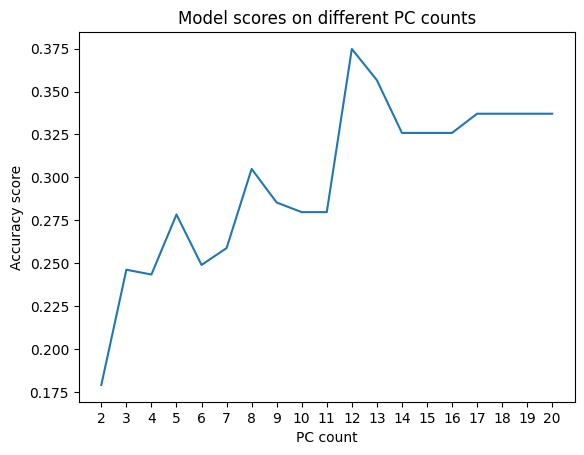

In [22]:
def ada(epochs):
  return AdaBoostClassifier(n_estimators=epochs)
model = train_and_predict(ada, all_data, 20, 100)

In [ ]:
x_tr, x_test, y_tr, y_test = train_test_split(all_data.iloc[:, :12], all_data['Population'], test_size=0.2, random_state=42)
model = ada(100)
model.fit(x_tr, y_tr)
y_pred = model.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.19      1.00      0.32         6
           2       0.00      0.00      0.00         8
           3       0.00      0.00      0.00         3
           4       1.00      1.00      1.00         5
           5       0.00      0.00      0.00         7
           6       0.00      0.00      0.00         4
           7       0.00      0.00      0.00         4
           8       1.00      1.00      1.00         2
           9       0.00      0.00      0.00         5
          10       0.00      0.00      0.00         5
          11       0.00      0.00      0.00         4
          12       0.00      0.00      0.00         5
          13       1.00      1.00      1.00         3
          14       1.00      1.00      1.00         3
          15       0.00      0.00      0.00        10
          16       0.00      0.00      0.00         7
          17       0.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Adaboost

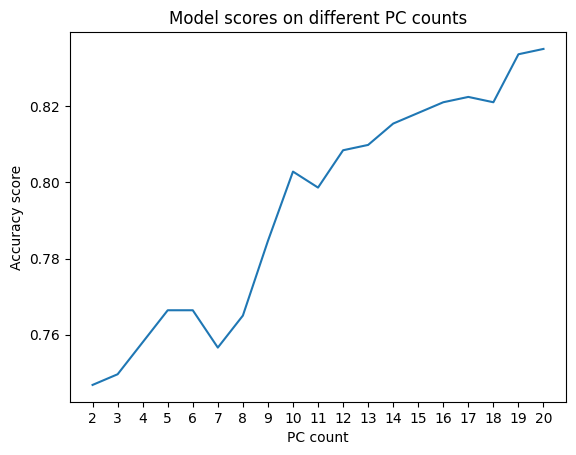

In [ ]:
def grad(epochs):
  return GradientBoostingClassifier(n_estimators=epochs)
model = train_and_predict(grad, all_data, 20, 100)

In [21]:
x_tr, x_test, y_tr, y_test = train_test_split(all_data.iloc[:, :19], all_data['Population'], test_size=0.2, random_state=42)
model = grad(100)
model.fit(x_tr, y_tr)
y_pred = model.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.62      0.83      0.71         6
           1       1.00      1.00      1.00         6
           2       1.00      1.00      1.00         8
           3       0.20      0.33      0.25         3
           4       1.00      1.00      1.00         5
           5       1.00      1.00      1.00         7
           6       0.29      0.50      0.36         4
           7       1.00      1.00      1.00         4
           8       1.00      1.00      1.00         2
           9       0.33      0.20      0.25         5
          10       1.00      1.00      1.00         5
          11       0.67      1.00      0.80         4
          12       0.56      1.00      0.71         5
          13       1.00      1.00      1.00         3
          14       1.00      1.00      1.00         3
          15       0.83      0.50      0.62        10
          16       1.00      0.86      0.92         7
          17       0.82    

Gradient Boosting

In [ ]:
populations.index('Ukrainian')

25